<a href="https://colab.research.google.com/github/nithinrb/NVIDIA/blob/main/DAY-9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install inference-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully un

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have reques

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="GjtVUBoK9aiIGmm125Nm")

print(rf.workspace())

loading Roboflow workspace...
{
  "name": "NITHINs Workspace",
  "url": "nithins-workspace-vemah",
  "projects": [
    "nithins-workspace-vemah/nithin-org"
  ]
}


In [16]:
from roboflow import Roboflow

rf = Roboflow(api_key="GjtVUBoK9aiIGmm125Nm")

workspace = rf.workspace("nithins-workspace-vemah")

project = workspace.project("nithin-org")

model = project.version(1).model

result = model.predict("/content/Zebra-finch-Taeniopygia-guttata-bird.webp").json()

print(result)

loading Roboflow workspace...
loading Roboflow project...
{'predictions': [{'inference_id': 'f9a3fe6e-b078-4189-8f01-47f090afc9b7', 'time': 0.0077176401391625404, 'image': {'width': 1600, 'height': 1058}, 'predictions': [{'class': 'cat', 'class_id': 0, 'confidence': 0.6516}], 'top': 'cat', 'confidence': 0.6516, 'image_path': '/content/Zebra-finch-Taeniopygia-guttata-bird.webp', 'prediction_type': 'ClassificationModel'}], 'image': (1600, 1058)}


In [17]:
import json

# Define the output file path
output_file = "prediction_results.json"

# Save the result dictionary to a JSON file
with open(output_file, 'w') as f:
    json.dump(result, f, indent=4)

print(f"Prediction results saved to {output_file}")

Prediction results saved to prediction_results.json




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



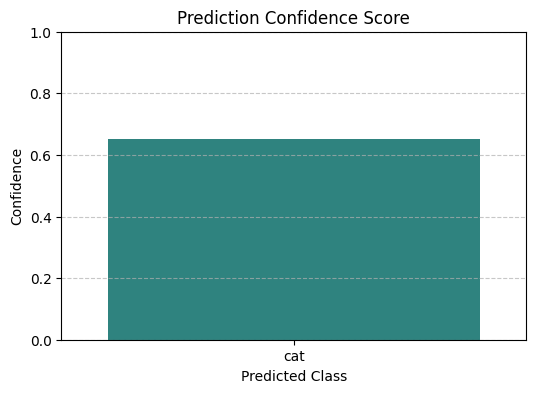

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract the class and confidence from the prediction result
if result and 'predictions' in result and result['predictions']:
    first_prediction = result['predictions'][0]
    if 'predictions' in first_prediction and first_prediction['predictions']:
        class_name = first_prediction['predictions'][0]['class']
        confidence = first_prediction['predictions'][0]['confidence']

        # Create a DataFrame for plotting
        data = {'Class': [class_name], 'Confidence': [confidence]}
        df_confidence = pd.DataFrame(data)

        # Create the bar plot
        plt.figure(figsize=(6, 4))
        sns.barplot(x='Class', y='Confidence', data=df_confidence, palette='viridis')
        plt.title('Prediction Confidence Score')
        plt.ylim(0, 1) # Confidence is between 0 and 1
        plt.ylabel('Confidence')
        plt.xlabel('Predicted Class')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print("No specific class predictions found in the result.")
else:
    print("No predictions found in the result.")

In [23]:
!pip install -q ultralytics
import cv2
from ultralytics import YOLO
from google.colab import files
from IPython.display import Video
from collections import Counter


print("Upload a video file...")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

print(f"Uploaded: {video_path}")


model = YOLO("yolov8n.pt")


animal_classes = {
    'bird',
    'cat',
    'dog',
    'horse',
    'sheep',
    'cow',
    'elephant',
    'bear',
    'zebra',
    'giraffe'
}



cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

output_video = "animal_detection_output.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    output_video,
    fourcc,
    fps,
    (width, height)
)


animal_counter = Counter()

frame_count = 0

print("Processing video...")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # Run YOLO detection
    results = model(frame, verbose=False)

    for r in results:

        boxes = r.boxes

        for box in boxes:

            cls_id = int(box.cls[0])

            label = model.names[cls_id]

            confidence = float(box.conf[0])

            # Only process animals
            if label in animal_classes:

                animal_counter[label] += 1

                x1, y1, x2, y2 = map(
                    int,
                    box.xyxy[0]
                )

                # Draw rectangle
                cv2.rectangle(
                    frame,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                text = f"{label} {confidence:.2f}"

                cv2.putText(
                    frame,
                    text,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 255, 0),
                    2
                )

    out.write(frame)

cap.release()
out.release()

print("\nVideo Processing Completed!")

print("\n===== DETECTED ANIMALS =====")

if len(animal_counter) == 0:
    print("No animals detected.")
else:
    for animal, count in animal_counter.items():
        print(f"{animal}: {count}")


print("\nProcessed Video:")

Video(output_video, embed=True)

files.download(output_video)

Upload a video file...


Saving 18359865-hd_1920_1080_30fps.mp4 to 18359865-hd_1920_1080_30fps.mp4
Uploaded: 18359865-hd_1920_1080_30fps.mp4
Processing video...

Video Processing Completed!

===== DETECTED ANIMALS =====
horse: 1899
cow: 15
bird: 34

Processed Video:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>